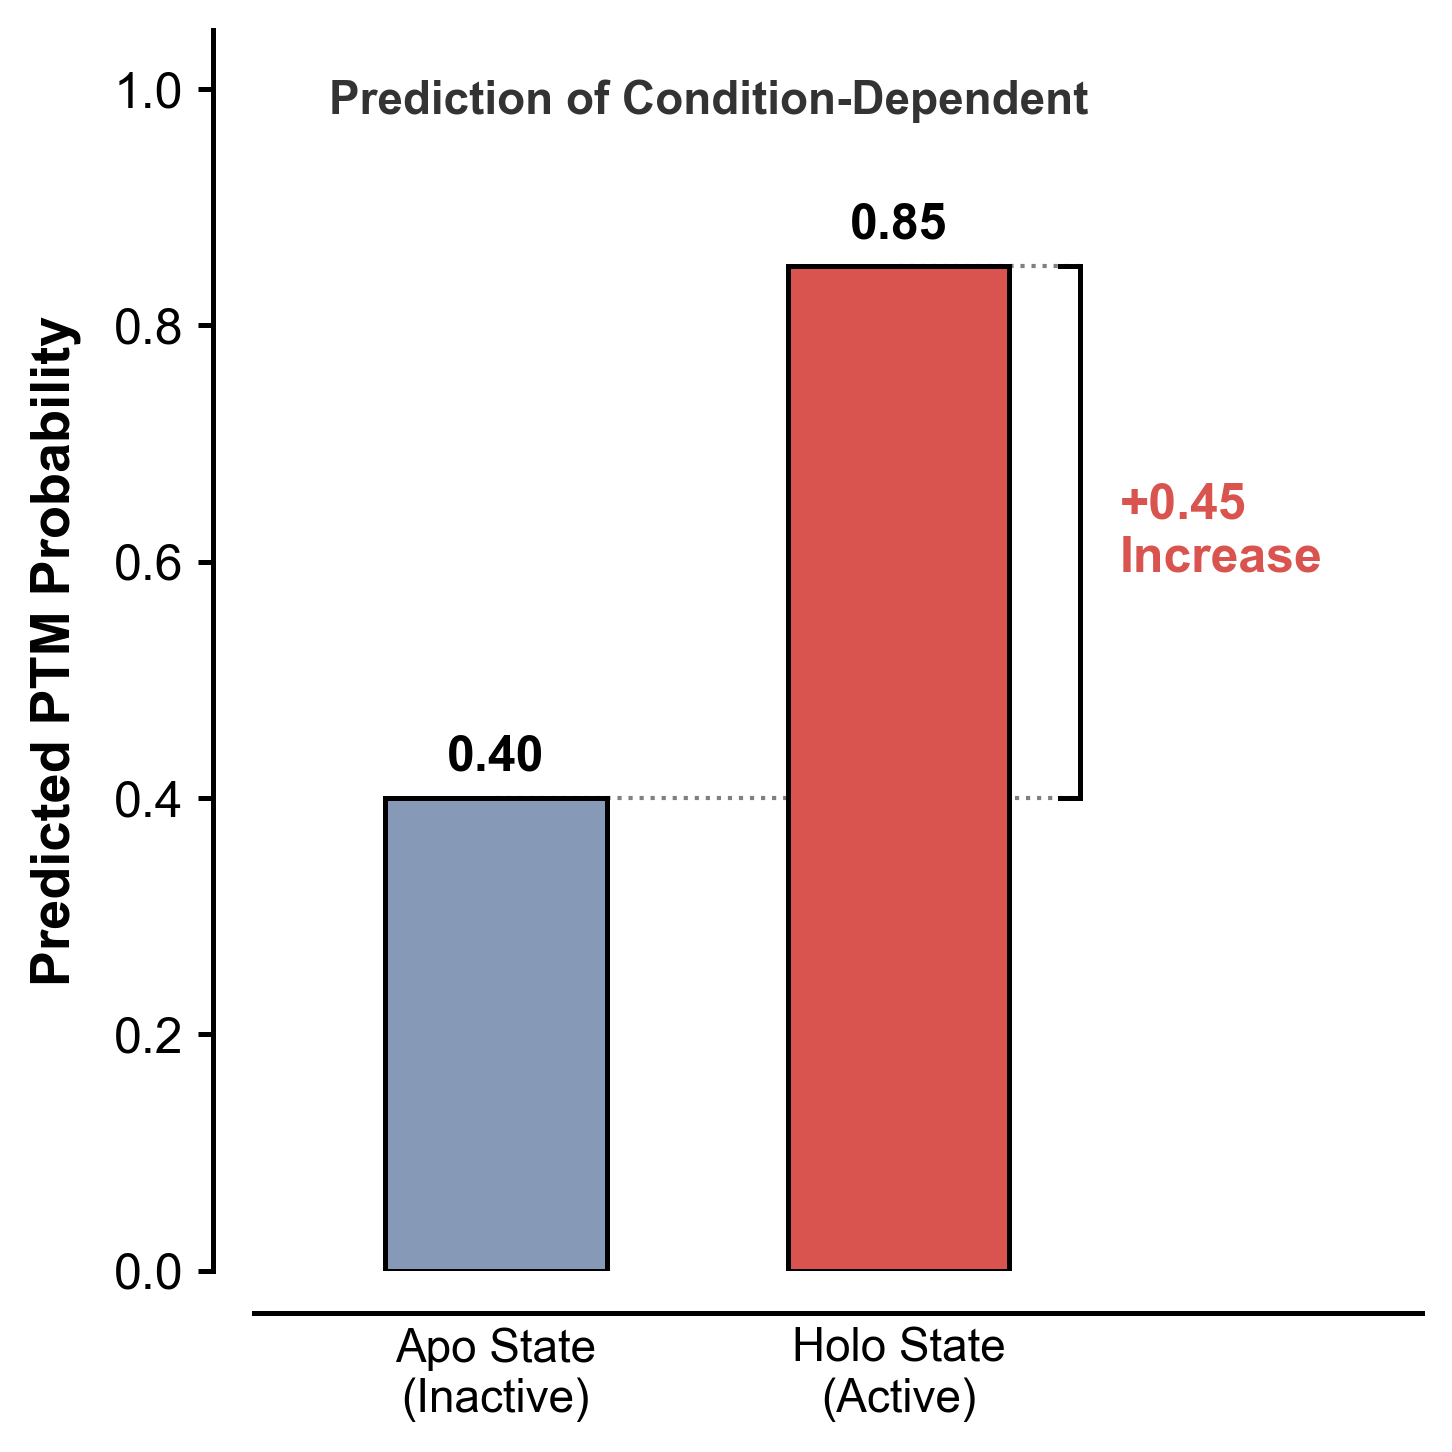

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 设置出版级绘图参数 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# --- 2. 数据准备 ---
states = ['Apo State\n(Inactive)', 'Holo State\n(Active)']
probabilities = [0.40, 0.85]
x_pos = [0, 1]

# --- 3. 专业配色 ---
color_inactive = '#869AB8'  # Muted Cool Blue-Grey
color_active = '#D9534F'    # Professional Red/Coral
colors = [color_inactive, color_active]

# --- 4. 创建画布 ---
# 稍微加宽画布以容纳右侧标注
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

# --- 5. 绘制柱状图 ---
bar_width = 0.55
bars = ax.bar(x_pos, probabilities, color=colors, width=bar_width, 
              edgecolor='black', linewidth=1.2, zorder=3)

# --- 6. 添加关键元素 ---

# A. 柱顶数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
            f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# B. 优化后的增量标注 (Right-Side Bracket)
y_start = probabilities[0]  # 0.40
y_end = probabilities[1]    # 0.85
# 定义标注的位置参数
bracket_x = 1.45  # 括号竖线的位置
text_x = 1.55     # 文字的位置

# 1. 绘制延伸虚线 (Extension Lines)
# 从柱子顶部延伸到括号位置，增强视觉引导
ax.plot([0, bracket_x], [y_start, y_start], color='gray', linestyle=':', linewidth=1.0, zorder=1)
ax.plot([1, bracket_x], [y_end, y_end], color='gray', linestyle=':', linewidth=1.0, zorder=1)

# 2. 绘制括号 (Bracket)
# 竖线
ax.plot([bracket_x, bracket_x], [y_start, y_end], color='black', linewidth=1.2)
# 上下短横线 (Ticks)
tick_len = 0.05
ax.plot([bracket_x - tick_len, bracket_x], [y_start, y_start], color='black', linewidth=1.2)
ax.plot([bracket_x - tick_len, bracket_x], [y_end, y_end], color='black', linewidth=1.2)

# 3. 添加文字和箭头
delta = y_end - y_start
mid_y = (y_start + y_end) / 2

# 使用 annotate 添加带箭头的文本
ax.annotate(f'+{delta:.2f}\nIncrease', 
            xy=(bracket_x, mid_y), 
            xytext=(text_x, mid_y),
            va='center', ha='left',
            fontsize=12, fontweight='bold', color=color_active,
            arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=0.0)) # 仅用于定位文本

# --- 7. 坐标轴调整 ---
ax.set_ylabel('Predicted PTM Probability', fontsize=13, fontweight='bold', labelpad=8)
ax.set_ylim(0, 1.05)
# 关键：扩展 X 轴范围，为右侧标注留出空间
ax.set_xlim(-0.6, 2.3)

# 隐藏多余边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

# X轴刻度
ax.set_xticks(x_pos)
ax.set_xticklabels(states, fontsize=11, fontweight='medium')
ax.tick_params(axis='x', length=0)
ax.text(0.4, 0.96, 'Prediction of Condition-Dependent  ', 
        transform=ax.transAxes, 
        ha='center', va='top', 
        fontsize=11, fontweight='bold', color='#333333')
# --- 8. 输出与保存 ---
plt.tight_layout()
plt.savefig('动力学信息验证图.png', dpi=500, bbox_inches='tight')
plt.show()

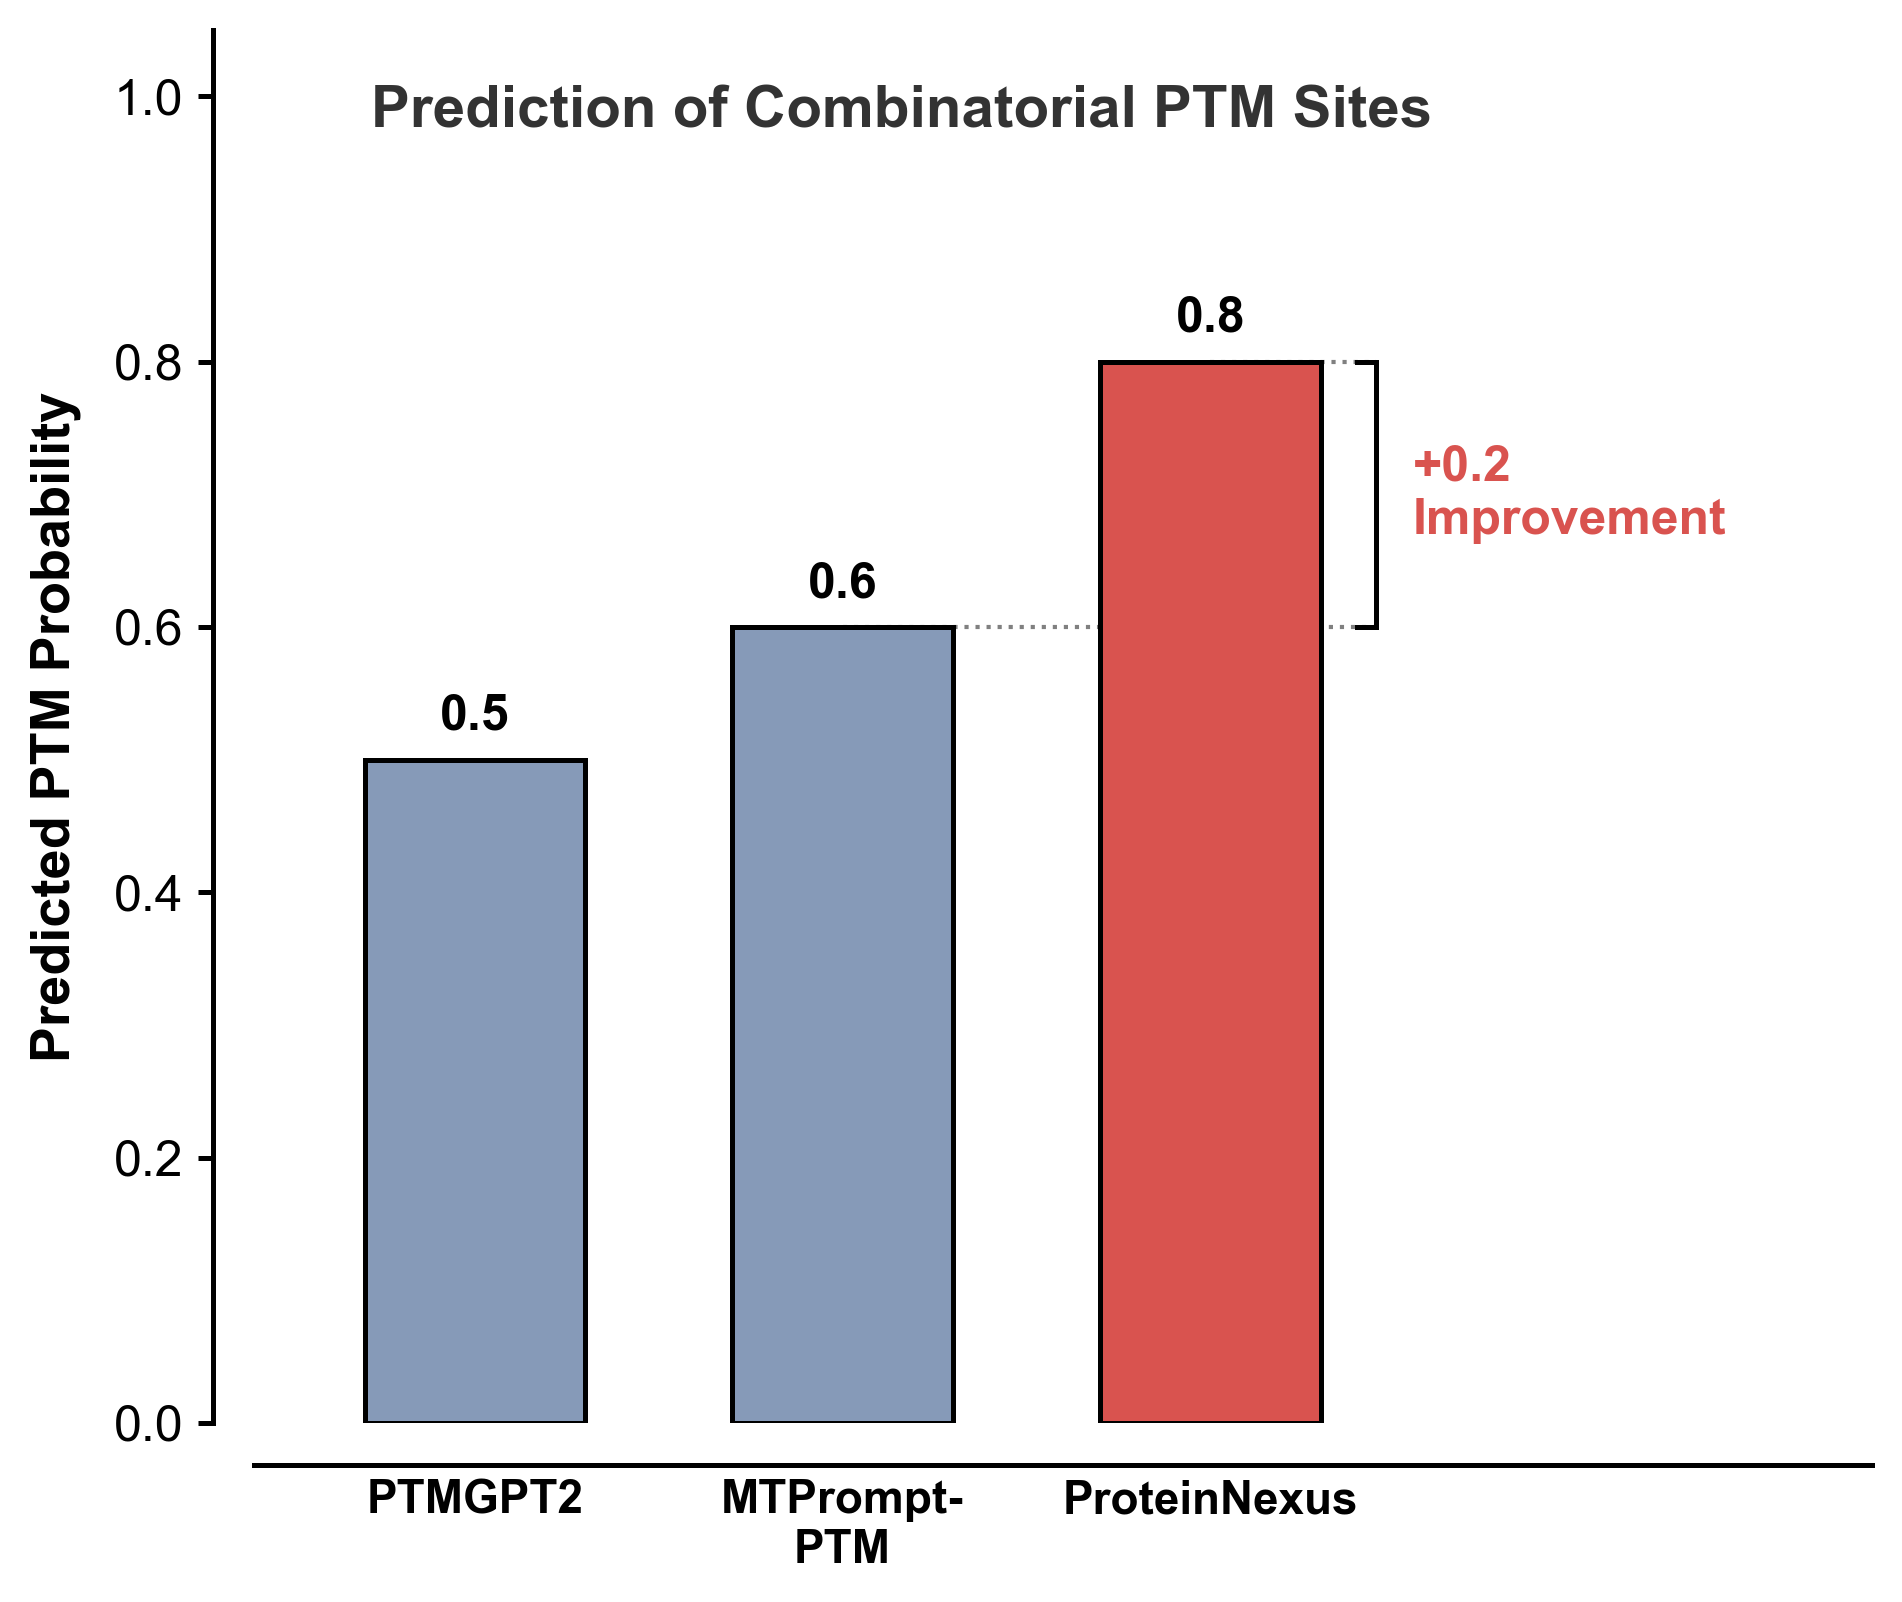

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 设置出版级绘图参数 ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2

# --- 2. 数据准备 ---
# 使用换行符 '\n' 防止x轴标签重叠
models = ['PTMGPT2', 'MTPrompt-\nPTM', 'ProteinNexus']
probabilities = [0.5, 0.6, 0.8]
x_pos = np.arange(len(models))

# --- 3. 专业配色 ---
color_compare = '#869AB8'    # Muted Cool Blue-Grey
color_highlight = '#D9534F'  # Professional Red/Coral
colors = [color_compare, color_compare, color_highlight]

# --- 4. 创建画布 ---
# 稍微增加高度以容纳内部标题
fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=300)

# --- 5. 绘制柱状图 ---
bar_width = 0.6
bars = ax.bar(x_pos, probabilities, color=colors, width=bar_width, 
              edgecolor='black', linewidth=1.2, zorder=3)

# --- 6. 添加关键元素 ---

# A. 柱顶数值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
            f'{height:.1f}', 
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# B. 右侧增量标注 (Right-Side Bracket)
y_runner_up = probabilities[1]  # 0.6
y_best = probabilities[2]       # 0.8

# 定义标注位置
bracket_x = 2.45
text_x = 2.55

# 1. 延伸虚线
ax.plot([1, bracket_x], [y_runner_up, y_runner_up], color='gray', linestyle=':', linewidth=1.0, zorder=1)
ax.plot([2, bracket_x], [y_best, y_best], color='gray', linestyle=':', linewidth=1.0, zorder=1)

# 2. 括号绘制
ax.plot([bracket_x, bracket_x], [y_runner_up, y_best], color='black', linewidth=1.2)
tick_len = 0.05
ax.plot([bracket_x - tick_len, bracket_x], [y_runner_up, y_runner_up], color='black', linewidth=1.2)
ax.plot([bracket_x - tick_len, bracket_x], [y_best, y_best], color='black', linewidth=1.2)

# 3. 文字和箭头
delta = y_best - y_runner_up
mid_y = (y_runner_up + y_best) / 2
ax.annotate(f'+{delta:.1f}\nImprovement', 
            xy=(bracket_x, mid_y), 
            xytext=(text_x, mid_y),
            va='center', ha='left',
            fontsize=12, fontweight='bold', color=color_highlight,
            arrowprops=dict(arrowstyle='-[, widthB=0.5, lengthB=0.5', lw=0.0))

# --- 7. 坐标轴调整 ---
ax.set_ylabel('Predicted PTM Probability', fontsize=13, fontweight='bold', labelpad=8)
# 关键：稍微增加 Y 轴上限，为内部标题留出空间
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.6, 3.8) # 确保右侧有足够空间

# 隐藏边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_position(('outward', 10))
ax.spines['bottom'].set_position(('outward', 10))

# X轴刻度
ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=11, fontweight='bold')
ax.tick_params(axis='x', length=0)

# --- 8. 添加优化后的标题 (In-Figure Title) ---
# 使用相对坐标 (transAxes) 将标题放置在图表内部顶部
ax.text(0.4, 0.96, 'Prediction of Combinatorial PTM Sites', 
        transform=ax.transAxes, 
        ha='center', va='top', 
        fontsize=14, fontweight='bold', color='#333333')

# --- 9. 输出 ---
plt.tight_layout()
plt.savefig('组合PTM位点图.png', dpi=500, bbox_inches='tight')
plt.show()

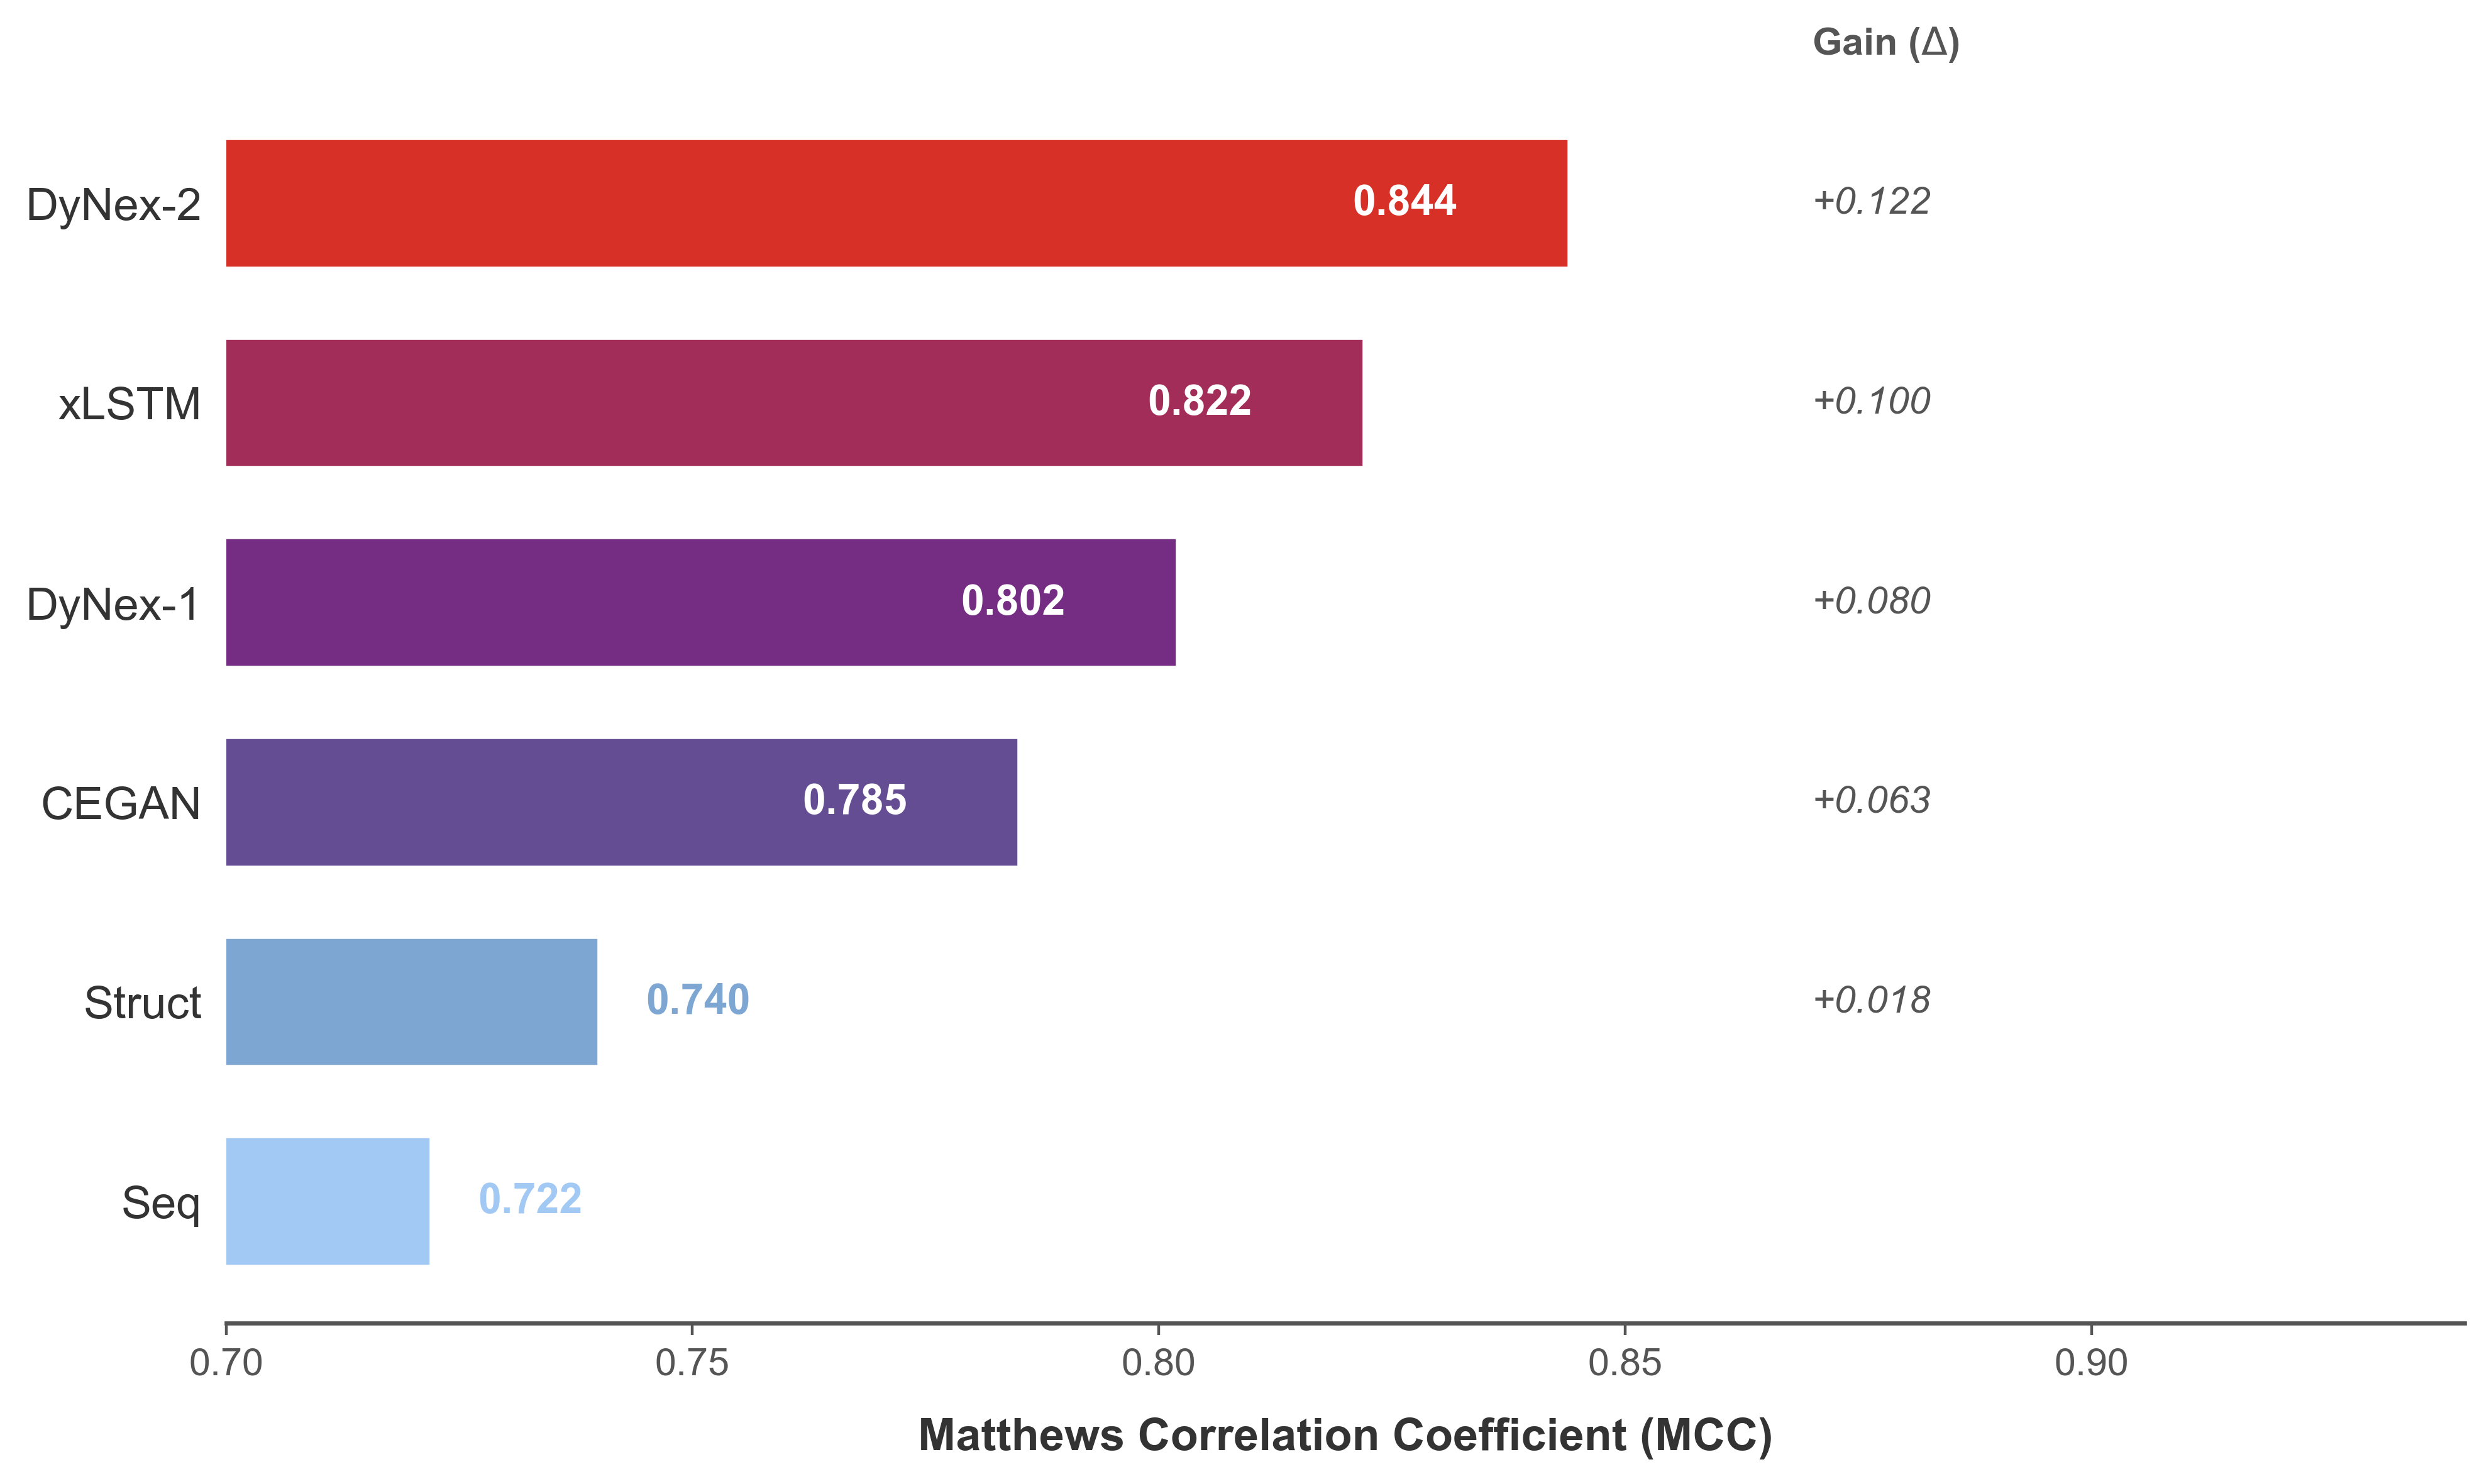

Corrected plot saved.


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# 1. 数据准备
data = {
    'Method': ['Seq', 'Struct', 'CEGAN', 'DyNex-1', 'xLSTM', 'DyNex-2'],
    'MCC': [0.722, 0.740, 0.785, 0.802, 0.822, 0.844]
}
df = pd.DataFrame(data)

# --- 核心修正：计算绝对提升 (Absolute Delta) ---
# 逻辑 A (推荐): 全部相对于 Baseline (Seq) 的总提升量
baseline_mcc = df.loc[df['Method'] == 'Seq', 'MCC'].values[0]
df['Delta'] = df['MCC'] - baseline_mcc

# 逻辑 B (备选): 相对于"上一行"的提升 (Step-wise Improvement)
# 如果您想展示每一步增加了多少，请取消下面这行的注释
# df['Delta'] = df['MCC'].diff().fillna(0)

# 2. 绘图设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig, ax = plt.subplots(figsize=(10, 6), dpi=400)

# 3. 配色方案 (数值映射渐变)
colors_list = ["#A1C9F4", "#4E79A7", "#762A83", "#D73027"] 
custom_cmap = mcolors.LinearSegmentedColormap.from_list("science_gradient", colors_list)
norm = mcolors.Normalize(vmin=df['MCC'].min(), vmax=df['MCC'].max())
bar_colors = [custom_cmap(norm(value)) for value in df['MCC']]

# 4. 绘制柱状图
bars = ax.barh(df['Method'], df['MCC'], color=bar_colors, height=0.65,
               edgecolor='white', linewidth=1.0, zorder=3)

# 5. 标注优化
for i, bar in enumerate(bars):
    width = bar.get_width()
    method = df.loc[i, 'Method']
    delta = df.loc[i, 'Delta']
    
    # 获取颜色亮度以自适应文字颜色
    r, g, b, _ = bar_colors[i]
    brightness = (r * 299 + g * 587 + b * 114) / 1000
    text_color_inner = 'white' if brightness < 0.65 else '#333333'
    
    # 5.1 标注绝对数值 MCC (柱子内部或外部)
    if width > 0.74:
        x_pos = width - 0.012
        ha = 'right'
        color = text_color_inner
    else:
        x_pos = width + 0.005
        ha = 'left'
        color = bar_colors[i]

    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}',
            ha=ha, va='center',
            fontsize=12, fontweight='bold', color=color)

    # 5.2 标注绝对提升量 (+0.xxx)
    # 修正点：不再显示百分比，而是显示绝对差值
    if method != 'Seq': 
        # 右侧对齐列
        ax.text(0.87, bar.get_y() + bar.get_height()/2, 
                f'+{delta:.3f}',  # 显示如 +0.122
                ha='left', va='center',
                fontsize=11, fontweight='normal', color='#555555',
                style='italic')

# 6. 装饰与布局
ax.set_xlim(0.70, 0.94) # 稍微加宽一点以容纳文字
# 添加列标题 (Header)，让图表更像表格，增加专业度
ax.text(0.87, len(df)-0.3, "Gain ($\Delta$)", ha='left', va='bottom', fontsize=11, fontweight='bold', color='#555555')

ax.set_xlabel("Matthews Correlation Coefficient (MCC)", fontsize=13, labelpad=10, fontweight='bold', color='#333333')

# 极简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('#555555')
ax.tick_params(axis='y', labelsize=13, left=False, labelcolor='#333333')
ax.tick_params(axis='x', labelsize=11, color='#555555', labelcolor='#555555')
# ax.xaxis.grid(True, linestyle='--', linewidth=0.8, color='#E0E0E0', zorder=0)

plt.tight_layout()
plt.savefig("ablation_study_delta_corrected-O.png", dpi=500, bbox_inches='tight')
# plt.savefig("ablation_study_delta_corrected.pdf", bbox_inches='tight')
plt.show()
print("Corrected plot saved.")

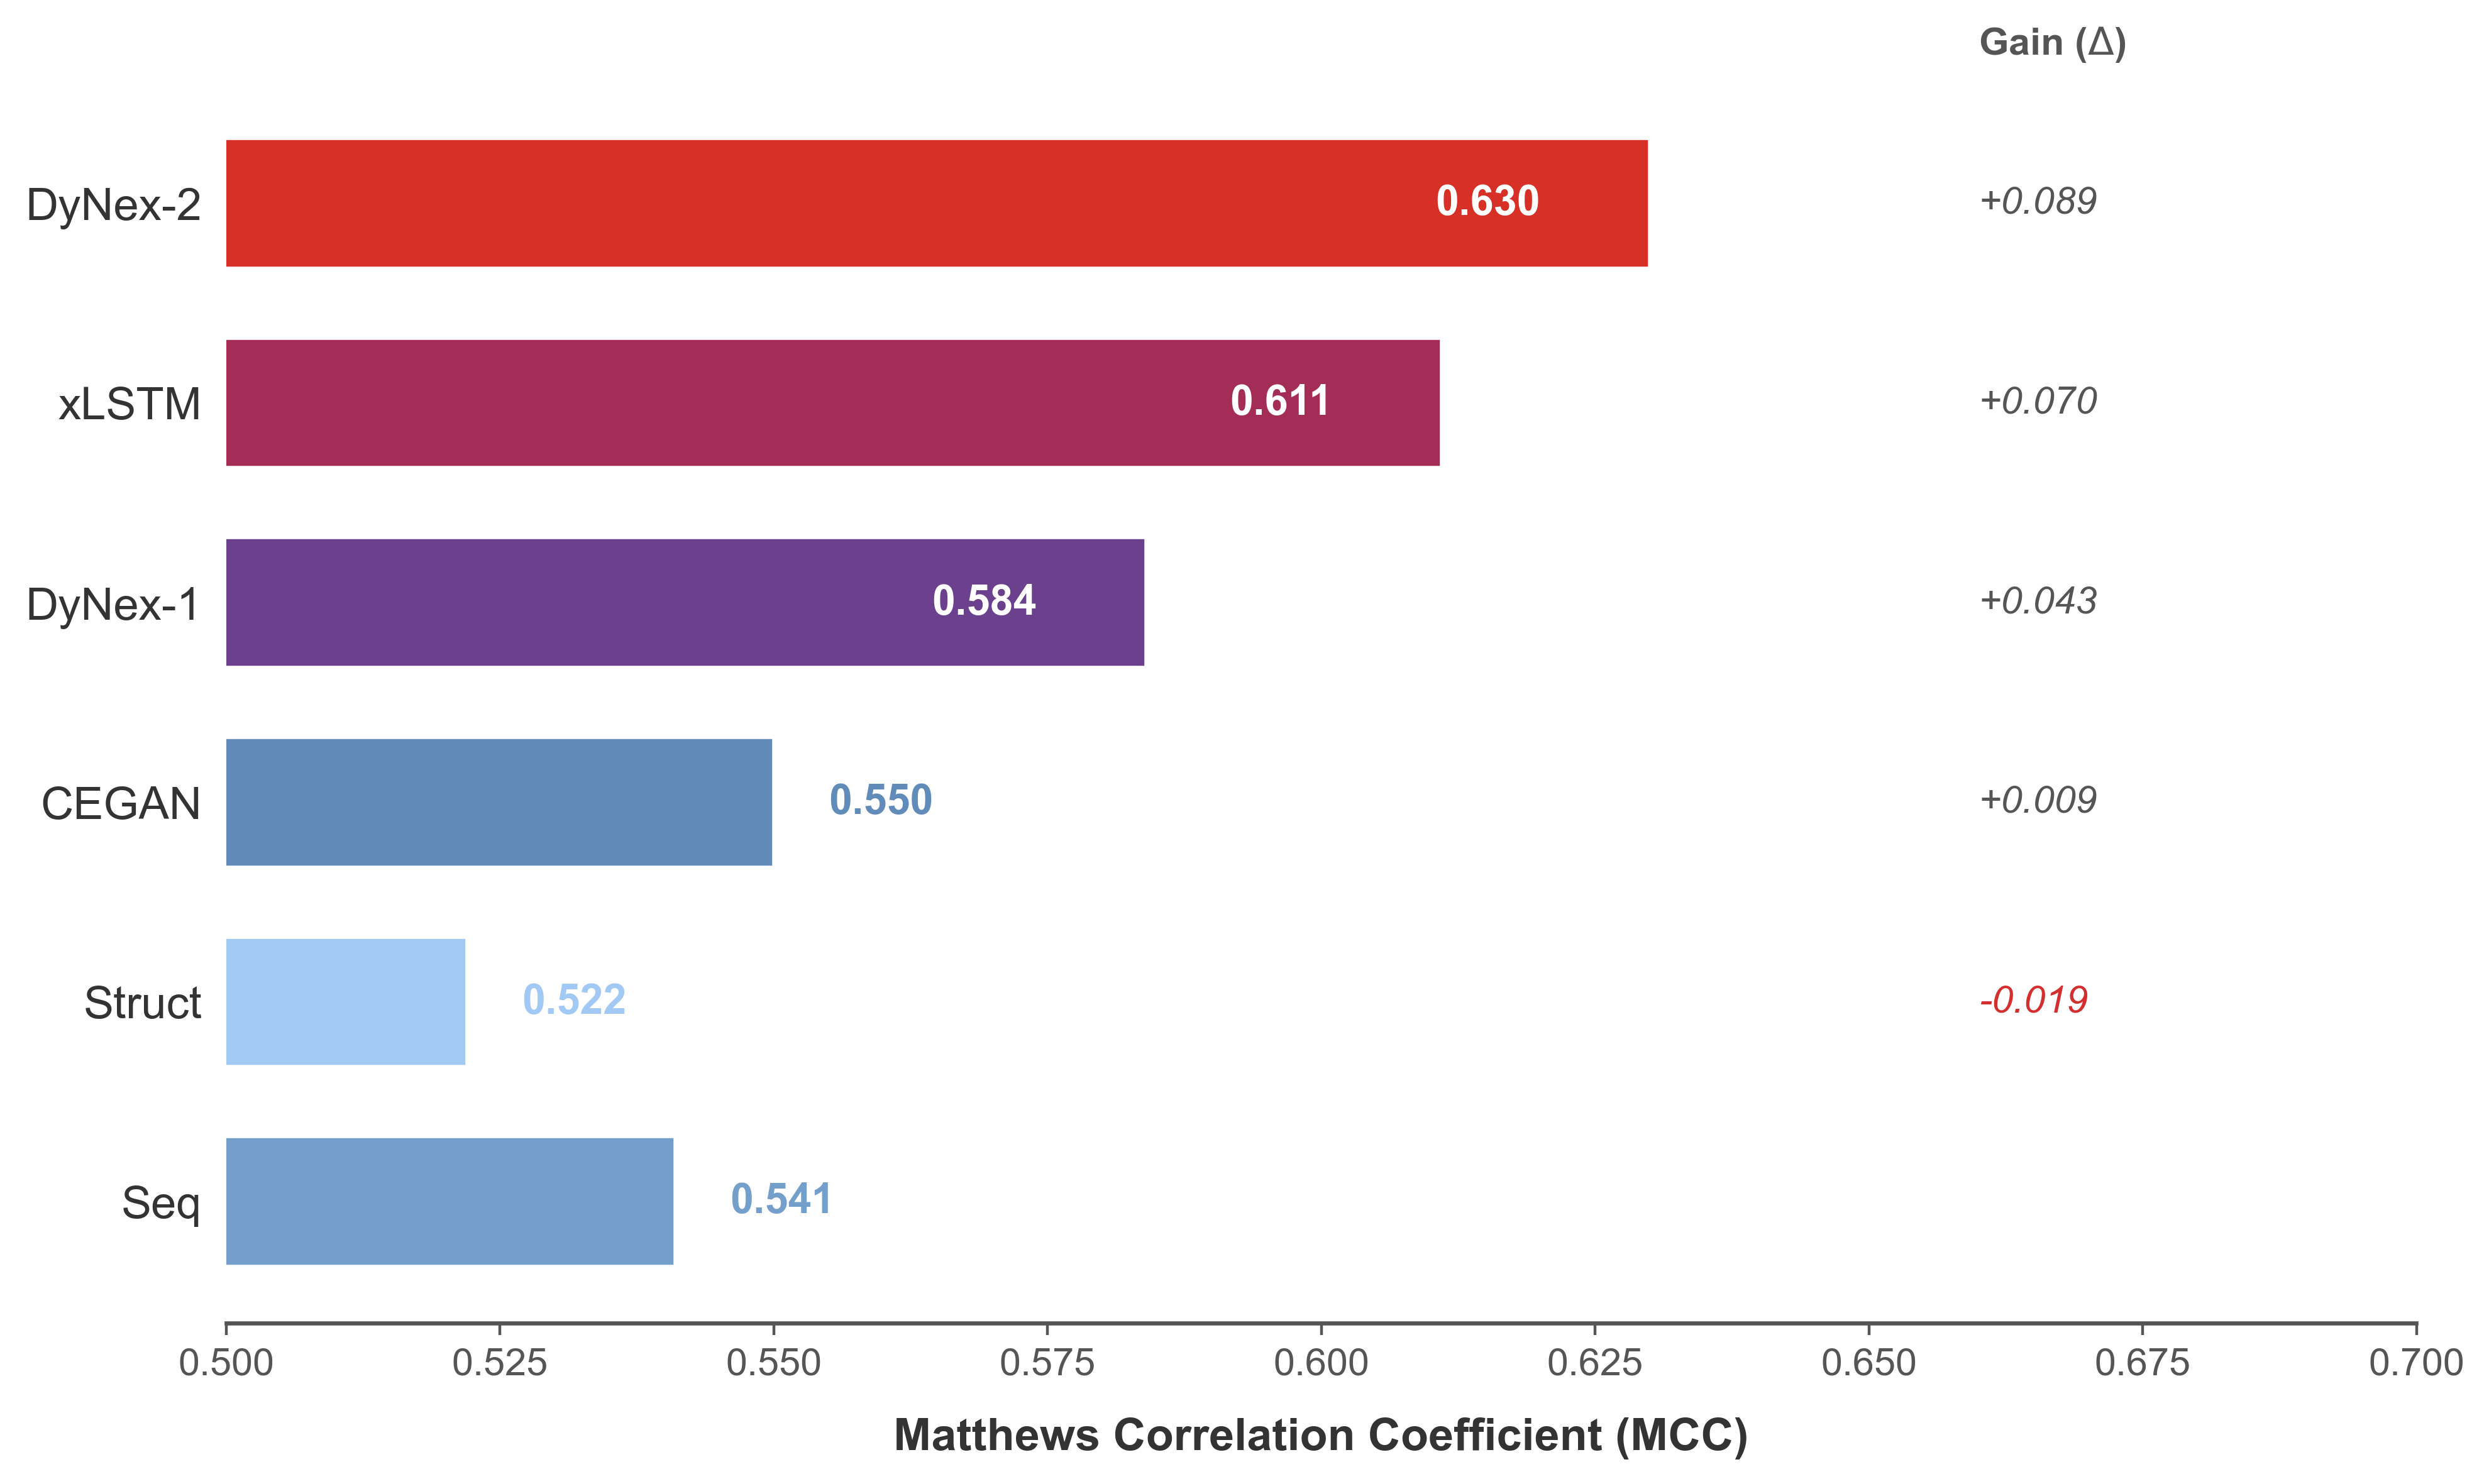

New experiment plot saved.


In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

# 1. 数据准备 (更新为新的一组数据)
data = {
    'Method': ['Seq', 'Struct', 'CEGAN', 'DyNex-1', 'xLSTM', 'DyNex-2'],
    'MCC': [0.541, 0.522, 0.550, 0.584, 0.611, 0.630]
}
df = pd.DataFrame(data)

# --- 计算绝对提升 (Absolute Delta) ---
baseline_mcc = df.loc[df['Method'] == 'Seq', 'MCC'].values[0]
df['Delta'] = df['MCC'] - baseline_mcc

# 2. 绘图设置
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
fig, ax = plt.subplots(figsize=(10, 6), dpi=400)

# 3. 配色方案 (数值映射渐变)
# 依然使用冷暖渐变，最低分(Struct)会自动获得最冷色，最高分(DyNex-2)获得最暖色
colors_list = ["#A1C9F4", "#4E79A7", "#762A83", "#D73027"] 
custom_cmap = mcolors.LinearSegmentedColormap.from_list("science_gradient", colors_list)
norm = mcolors.Normalize(vmin=df['MCC'].min(), vmax=df['MCC'].max())
bar_colors = [custom_cmap(norm(value)) for value in df['MCC']]

# 4. 绘制柱状图
bars = ax.barh(df['Method'], df['MCC'], color=bar_colors, height=0.65,
               edgecolor='white', linewidth=1.0, zorder=3)

# 5. 标注优化
for i, bar in enumerate(bars):
    width = bar.get_width()
    method = df.loc[i, 'Method']
    delta = df.loc[i, 'Delta']
    
    # 获取颜色亮度以自适应文字颜色
    r, g, b, _ = bar_colors[i]
    brightness = (r * 299 + g * 587 + b * 114) / 1000
    text_color_inner = 'white' if brightness < 0.65 else '#333333'
    
    # 5.1 标注绝对数值 MCC
    # 阈值调整：因为这组数据最大只有0.63，我们将内嵌文字的阈值下调到0.57左右
    if width > 0.57:
        x_pos = width - 0.01
        ha = 'right'
        color = text_color_inner
    else:
        x_pos = width + 0.005
        ha = 'left'
        color = bar_colors[i] # 外部文字颜色与柱子一致

    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{width:.3f}',
            ha=ha, va='center',
            fontsize=12, fontweight='bold', color=color)

    # 5.2 标注绝对提升量 (+/- Delta)
    if method != 'Seq': 
        # 设置正负号格式：+:正数, -:负数
        delta_str = f'{delta:+.3f}' # 自动添加正负号
        
        # 负值可以用特殊颜色标记（例如灰色或黑色），正值保持默认
        delta_color = '#555555' if delta >= 0 else '#D32F2F' # 负值用红色警示
        
        # 右侧对齐列位置调整：因为X轴范围变了，这里设为 0.66
        ax.text(0.66, bar.get_y() + bar.get_height()/2, 
                delta_str,
                ha='left', va='center',
                fontsize=11, fontweight='normal', color=delta_color,
                style='italic')

# 6. 装饰与布局
ax.set_xlim(0.50, 0.70) # !!! 关键调整：适配新数据范围 [0.52, 0.63]

# 添加列标题
ax.text(0.66, len(df)-0.3, "Gain ($\Delta$)", ha='left', va='bottom', fontsize=11, fontweight='bold', color='#555555')

ax.set_xlabel("Matthews Correlation Coefficient (MCC)", fontsize=13, labelpad=10, fontweight='bold', color='#333333')

# 极简边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.2)
ax.spines['bottom'].set_color('#555555')
ax.tick_params(axis='y', labelsize=13, left=False, labelcolor='#333333')
ax.tick_params(axis='x', labelsize=11, color='#555555', labelcolor='#555555')
# ax.xaxis.grid(True, linestyle='--', linewidth=0.8, color='#E0E0E0', zorder=0)

plt.tight_layout()
plt.savefig("ablation_study_set2-C.png", dpi=500, bbox_inches='tight')
# plt.savefig("ablation_study_set2.pdf", bbox_inches='tight')
plt.show()
print("New experiment plot saved.")

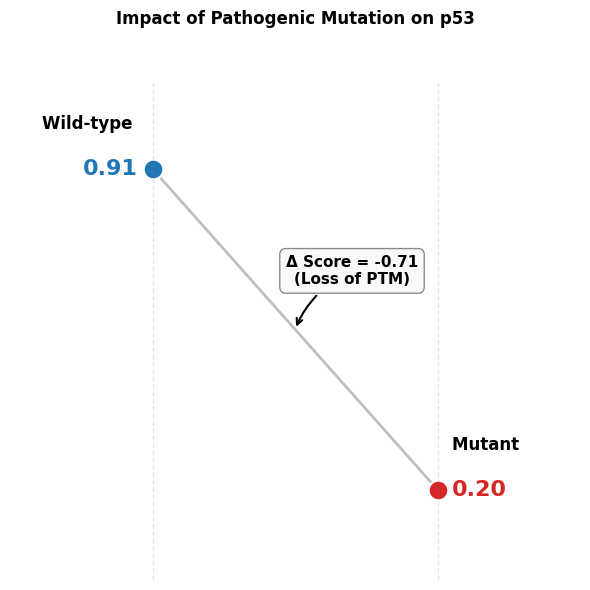

In [3]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. 数据准备
conditions = ['Wild-type ', 'Mutant ']
values = [0.91, 0.20]
colors = ['#1f77b4', '#d62728']  # 蓝色 (WT), 红色 (Mutant)

# 创建画布
fig, ax = plt.subplots(figsize=(6, 6))

# 定义 X 轴坐标 (0 和 1)
x_left = 0
x_right = 1

# 2. 绘制连接线 (The Slope)
# zorder=1 确保线在点下面
ax.plot([x_left, x_right], [values[0], values[1]], color='gray', alpha=0.5, linewidth=2, zorder=1)

# 3. 绘制数据点 (The Points)
# s=200 设置点的大小
ax.scatter([x_left], [values[0]], color=colors[0], s=200, zorder=2, edgecolors='white', linewidth=1.5)
ax.scatter([x_right], [values[1]], color=colors[1], s=200, zorder=2, edgecolors='white', linewidth=1.5)

# 4. 添加数值标签 (Values)
# 左侧数值
ax.text(x_left - 0.05, values[0], f'{values[0]:.2f}', 
        ha='right', va='center', fontsize=16, fontweight='bold', color=colors[0])
# 右侧数值
ax.text(x_right + 0.05, values[1], f'{values[1]:.2f}', 
        ha='left', va='center', fontsize=16, fontweight='bold', color=colors[1])

# 5. 添加条件标签 (Labels)
# 左侧标签 (Wild-type)
ax.text(x_left - 0.05, values[0] + 0.08, conditions[0], 
        ha='right', va='bottom', fontsize=12, fontweight='bold', color='black')
# 右侧标签 (Mutant)
ax.text(x_right + 0.05, values[1] + 0.08, conditions[1], 
        ha='left', va='bottom', fontsize=12, fontweight='bold', color='black')

# 6. 添加 Δ Score 标注
mid_x = (x_left + x_right) / 2
mid_y = (values[0] + values[1]) / 2
delta = values[0] - values[1]

ax.annotate(
    f'Δ Score = -{delta:.2f}\n(Loss of PTM)',
    xy=(mid_x, mid_y), 
    xytext=(mid_x + 0.2, mid_y + 0.1),
    arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.2", color='black', lw=1.5),
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="#f9f9f9", ec="gray", alpha=0.9)
)

# 7. 绘制垂直轴线 (模拟坐标轴)
ax.vlines(x=x_left, ymin=0, ymax=1.1, color='gray', alpha=0.2, linewidth=1, linestyles='--')
ax.vlines(x=x_right, ymin=0, ymax=1.1, color='gray', alpha=0.2, linewidth=1, linestyles='--')

# 美化图表
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1.2)
ax.axis('off')  # 隐藏坐标轴

# 标题
plt.title('Impact of Pathogenic Mutation on p53', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig("致病突变-1.png", dpi=500, bbox_inches='tight')
plt.show()

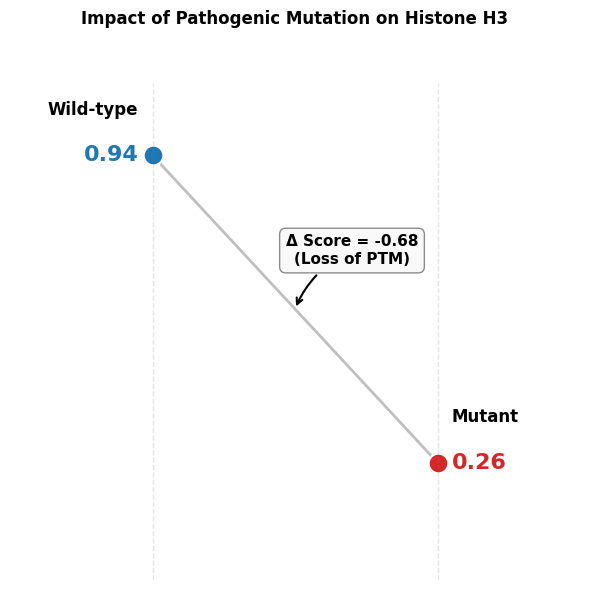

In [5]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. 数据准备
conditions = ['Wild-type', 'Mutant']
values = [0.94, 0.26]
colors = ['#1f77b4', '#d62728']  # 蓝色 (WT), 红色 (Mutant)

# 创建画布
fig, ax = plt.subplots(figsize=(6, 6))

# 定义 X 轴坐标 (0 和 1)
x_left = 0
x_right = 1

# 2. 绘制连接线 (The Slope)
# zorder=1 确保线在点下面
ax.plot([x_left, x_right], [values[0], values[1]], color='gray', alpha=0.5, linewidth=2, zorder=1)

# 3. 绘制数据点 (The Points)
# s=200 设置点的大小
ax.scatter([x_left], [values[0]], color=colors[0], s=200, zorder=2, edgecolors='white', linewidth=1.5)
ax.scatter([x_right], [values[1]], color=colors[1], s=200, zorder=2, edgecolors='white', linewidth=1.5)

# 4. 添加数值标签 (Values)
# 左侧数值
ax.text(x_left - 0.05, values[0], f'{values[0]:.2f}', 
        ha='right', va='center', fontsize=16, fontweight='bold', color=colors[0])
# 右侧数值
ax.text(x_right + 0.05, values[1], f'{values[1]:.2f}', 
        ha='left', va='center', fontsize=16, fontweight='bold', color=colors[1])

# 5. 添加条件标签 (Labels)
# 左侧标签 (Wild-type)
ax.text(x_left - 0.05, values[0] + 0.08, conditions[0], 
        ha='right', va='bottom', fontsize=12, fontweight='bold', color='black')
# 右侧标签 (Mutant)
ax.text(x_right + 0.05, values[1] + 0.08, conditions[1], 
        ha='left', va='bottom', fontsize=12, fontweight='bold', color='black')

# 6. 添加 Δ Score 标注
mid_x = (x_left + x_right) / 2
mid_y = (values[0] + values[1]) / 2
delta = values[0] - values[1]

ax.annotate(
    f'Δ Score = -{delta:.2f}\n(Loss of PTM)',
    xy=(mid_x, mid_y), 
    xytext=(mid_x + 0.2, mid_y + 0.1),
    arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=0.2", color='black', lw=1.5),
    ha='center', fontsize=11, fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.4", fc="#f9f9f9", ec="gray", alpha=0.9)
)

# 7. 绘制垂直轴线 (模拟坐标轴)
ax.vlines(x=x_left, ymin=0, ymax=1.1, color='gray', alpha=0.2, linewidth=1, linestyles='--')
ax.vlines(x=x_right, ymin=0, ymax=1.1, color='gray', alpha=0.2, linewidth=1, linestyles='--')

# 美化图表
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1.2)
ax.axis('off')  # 隐藏坐标轴

# 标题
plt.title('Impact of Pathogenic Mutation on Histone H3', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig("致病突变-2.png", dpi=500, bbox_inches='tight')
plt.show()